# Dimensionality Reduction – Heart Failure Prediction Dataset
*Linear, Nonlinear, and Model-Based Embedding Methods (PCA, t-SNE, UMAP, LDA, XGBoost Leaf Embeddings)*

---
## Table of Contents
1. [Setup](#setup)  
    1.1 [Imports and Reproducibility](#imports-and-reproducibility)  
    1.2 [Data Loading](#data-loading)  

2. [Linear Methods](#linear-methods)  
    2.1 [PCA](#pca)  
    2.2 [LDA (1D Supervised)](#lda)  

3. [Nonlinear Methods – Unsupervised](#nonlinear-unsupervised)  
    3.1 [t-SNE](#tsne)  
    3.2 [UMAP (Unsupervised)](#umap-unsupervised)  
    3.3 [Hybrid Mix (UMAP1 + UMAP2 + LDA1)](#mix)  

4. [Nonlinear Methods – Supervised/Semi-supervised](#nonlinear-supervised)  
    4.1 [UMAP (Supervised)](#umap-supervised)  
    4.2 [UMAP (Semi-supervised)](#umap-semisupervised)  
    4.3 [XGBoost Leaf Embedding + UMAP](#xgb-leaf-umap)  

5. [Conclusions](#conclusions)  
   5.1 [Next Steps](#next-steps)  

<a id="setup"></a>
## Setup

---
<a id="imports-and-reproducibility"></a>
### Imports and Reproducibility

In [ ]:
import os, sys, joblib, numpy as np, pandas as pd, umap as u, matplotlib.pyplot as plt
sys.path.append(os.path.abspath(os.path.join('..')))

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from scripts.dim_red import *
from copy import deepcopy
from sklearn.model_selection import StratifiedKFold
from scripts.eda.preprocessing.pipeline import build_preprocessing_pipeline
from xgboost import XGBClassifier

SEED = 42
OUTPUT_DIR = "../outputs/dim_red"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, 'embeddings'), exist_ok=True)

<a id="data-loading"></a>
### Data Loading

In [3]:
df_cleaned = joblib.load("../outputs/eda/df_cleaned.pkl")
df_copy = df_cleaned.copy()

X = df_copy.iloc[:, :-1]
y = df_copy.iloc[:, -1]

TARGET_COL = 'DEATH_EVENT'
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

In [ ]:
_full_preproc = build_preprocessing_pipeline()
preproc_no_balance = deepcopy(_full_preproc)
preproc_no_balance.steps = preproc_no_balance.steps[:-1]   # no balancing for now

balancer = _full_preproc.steps[-1][1]  # SMOTEENN

X_p = preproc_no_balance.fit_transform(X, y)

<a id="feature-prunning"></a>
### Feature Pruning

In [5]:
cols_to_drop = ['high_blood_pressure', 'platelets', 'sex', 'creatinine_phosphokinase', 'anaemia', 'smoking', 'diabetes']
X_p_reduced = X_p.drop(columns=cols_to_drop)

<a id="linear-methods"></a>
## Linear Methods
---

<a id="pca"></a>
### PCA

#### Variance Explained

Explained variance ratio: [0.35510402 0.2336299  0.18559905 0.1274141  0.09825292]
Total variance retained: 0.9999999999999999
Variance kept by first 3 PCs: 0.774


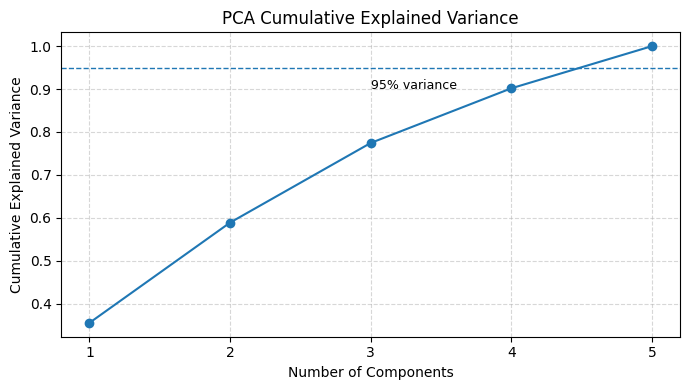

In [6]:
pca_full = PCA(random_state=SEED)
pca_full.fit(X_p_reduced)
explained_variance = pca_full.explained_variance_ratio_

print("Explained variance ratio:", explained_variance)
print("Total variance retained:", np.sum(explained_variance))
print("Variance kept by first 3 PCs:", round(explained_variance[:3].sum(), 3))
plot_cumulative_variance(explained_variance, show_target=0.95)

- The first component explains ~35.51% of the total variance.
- The first three components together explain ~77.4% of the variance.
- 4 to 5 components are needed to reach 95% variance.

#### 3D PCA

In [7]:
pca = PCA(n_components=3, random_state=SEED)
X_pca = pca.fit_transform(X_p_reduced)

df_pca = pd.DataFrame(X_pca, columns=["PCA_1", "PCA_2", "PCA_3"])
joblib.dump(df_pca, "../outputs/dim_red/embeddings/X_pca.pkl")

df_pca["DEATH_EVENT"] = y.values

joblib.dump(df_pca, "../outputs/dim_red/df_pca.pkl")
plot_3d(X_pca, y, algorithm="PCA")

- The outcome classes strongly overlap, with no clear cluster separation.

- The first three principal components capture overall variance in the data, but this variance is not aligned with the outcome variable.

- Class differences are **not linearly separable** and are not represented along the dominant variance directions.

- Important discriminative **patterns are non-linear or depend on feature interactions**.

<a id="lda"></a>
### LDA (1D Supervised)

Text(0.5, 1.0, 'LDA 1D Projection')

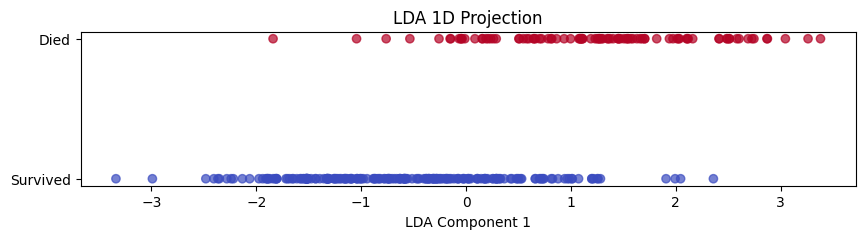

In [8]:
lda = LinearDiscriminantAnalysis()
X_lda = lda.fit_transform(X_p_reduced, y)

df_lda = pd.DataFrame(X_lda, columns=["LDA_1"])
joblib.dump(df_lda, "../outputs/dim_red/embeddings/X_lda.pkl")

df_lda[TARGET_COL] = y.values
joblib.dump(df_lda, os.path.join(OUTPUT_DIR, 'df_lda.pkl'))

plt.figure(figsize=(10,2))
plt.scatter(X_lda, y, c=y, cmap='coolwarm', alpha=0.7)
plt.xlabel("LDA Component 1")
plt.yticks([0,1], ["Survived","Died"])
plt.title("LDA 1D Projection")

- Classes show clear separation in central tendency, meaning the features contain **useful discriminative information**.

- The substantial overlap confirms that the **dataset is not linearly separable**.

- This explains why nonlinear models (XGBoost, RF, SVM RBF) outperform linear ones.

<a id="nonlinear-supervised"></a>
## Nonlinear Methods – Unsupervised
---

<a id="tsne"></a>
### t-SNE

In [9]:
tsne = TSNE(n_components=3, perplexity=50, init="pca", random_state=SEED)
X_tsne = tsne.fit_transform(X_p_reduced)

df_tsne = pd.DataFrame(X_tsne, columns=["tSNE_1", "tSNE_2", "tSNE_3"])
df_tsne[TARGET_COL] = y.values
plot_3d(X_tsne, y, algorithm="t-SNE")

- Compared to PCA, t-SNE highlights stronger local structure, with visible regions where samples with the same outcome tend to group together.

- Considerable overlap between the two classes remains, and no clearly separated clusters are formed.

- The embedding shows gradual transitions, rather than sharp class boundaries.

- Outcome-related patterns are non-linear and locally expressed, but not strong enough to produce fully isolated groups.

<a id="umap-unsupervised"></a>
### UMAP (Unsupervised)

In [16]:
umap_unsup = u.UMAP(n_components=3, n_neighbors=10, min_dist=0.0, metric="manhattan", random_state=SEED)
X_umap_unsup = umap_unsup.fit_transform(X_p_reduced)

df_umap_unsup = pd.DataFrame(X_umap_unsup, columns=["UMAP_1", "UMAP_2", "UMAP_3"])
joblib.dump(df_umap_unsup, "../outputs/dim_red/embeddings/X_umap_unsupervised.pkl")

df_umap_unsup[TARGET_COL] = y.values

joblib.dump(df_umap_unsup, os.path.join(OUTPUT_DIR, 'df_umap_unsupervised.pkl'))
plot_3d(X_umap_unsup, y, algorithm="UMAP")

d:\OneDrive - Politechnika Łódzka\Dokumenty\TUL\semester7\inzynierka\cardio-risk-prediction\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



- UMAP reveals clear non-linear structure in the data, 

- Several continuous, curved regions, rather than random scatter, have formed.

- Some regions have more instances of one class, but both outcome classes still coexist within most structures.
  
- There are no fully isolated clusters indicates that class differences are distributed along shared manifolds, rather than forming distinct groups.

<a id="mix"></a>
### Hybrid Mix (UMAP1 + UMAP2 + LDA1)

In [11]:
X_combined = pd.DataFrame({
    "UMAP_1": X_umap_unsup[:, 0],
    "UMAP_2": X_umap_unsup[:, 1],
    "LDA_1": X_lda[:, 0],
})

joblib.dump(X_combined, "../outputs/dim_red/embeddings/X_mix.pkl")

df_mix = pd.concat(
    [pd.DataFrame(X_combined, columns=X_combined.columns),
     pd.Series(y, name=TARGET_COL)],
    axis=1
)

joblib.dump(df_mix, os.path.join(OUTPUT_DIR, 'df_mix.pkl'))
plot_3d(X_combined, y, algorithm="UMAP1 + UMAP2 + LDA1")

- The combined embedding shows a more structured arrangement than PCA or UMAP alone, with smoother trajectories and clearer ordering of samples.

- LDA adds a discriminative direction that slightly shifts class distributions, especially along one axis, but does not fully separate the classes.

- Some regions exhibit stronger class tendencies (local dominance of one class), yet substantial overlap remains across most of the space.

- The class information exists but is distributed across multiple dimensions and scales.

<a id="nonlinear-supervised"></a>
## Nonlinear Methods – Supervised/Semi-supervised
---

<a id="umap-supervised"></a>
### UMAP (Supervised)

In [12]:
umap_sup = u.UMAP(n_components=3, n_neighbors=10, target_weight=0.7, random_state=SEED)
X_umap_sup = umap_sup.fit_transform(X_p_reduced, y)

df_umap_sup = pd.DataFrame(X_umap_sup, columns=["UMAP_SUP_1", "UMAP_SUP_2", "UMAP_SUP_3"])
joblib.dump(df_umap_sup, "../outputs/dim_red/embeddings/X_umap_supervised.pkl")

df_umap_sup[TARGET_COL] = y.values

joblib.dump(df_umap_sup, os.path.join(OUTPUT_DIR, 'df_umap_supervised.pkl'))
plot_3d(X_umap_sup, y, algorithm="UMAP (supervised)")

d:\OneDrive - Politechnika Łódzka\Dokumenty\TUL\semester7\inzynierka\cardio-risk-prediction\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



- Classes are clearly separated, with each group forming a compact region in the embedding space.

- The classes are almost perfectly separated, with one probable anomaly.

- The embedding reflects class-aware structure, not overfitting — the separation is smooth and geometrically consistent.

- Supports the use of nonlinear classifiers and ensemble models, which can exploit this separability.

<a id="umap-semisupervised"></a>
### UMAP (Semi-supervised)

In [13]:
umap_semi = u.UMAP(n_components=3, n_neighbors=10, target_weight=0.2, metric="manhattan", random_state=SEED)
X_umap_semi = umap_semi.fit_transform(X_p_reduced, y)

df_umap_semi = pd.DataFrame(X_umap_semi, columns=["UMAP_SEMI_1", "UMAP_SEMI_2", "UMAP_SEMI_3"])
joblib.dump(df_umap_semi, "../outputs/dim_red/embeddings/X_umap_semisupervised.pkl")

df_umap_semi[TARGET_COL] = y.values

joblib.dump(df_umap_semi, os.path.join(OUTPUT_DIR, 'df_umap_semisupervised.pkl'))
plot_3d(X_umap_semi, y, algorithm="UMAP (semi-supervised)")

d:\OneDrive - Politechnika Łódzka\Dokumenty\TUL\semester7\inzynierka\cardio-risk-prediction\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



- The classes are clearly separated, but the separation is slightly weaker than in fully supervised UMAP.

- Label information influences the embedding, but the original data structure is still largely preserved.

- The separation is nearly perfect, with a singular points likely being an anomaly.

- The embedding balances class information and data geometry, rather than forcing strict separation.

- Partial supervision is sufficient to reveal meaningful structure.

<a id="xgb-leaf-umap"></a>
### XGBoost Leaf Embedding + UMAP

In [45]:
xgb = XGBClassifier(n_estimators=600, max_depth=5, learning_rate=0.01, subsample=0.8, colsample_bytree=0.8, min_child_weight=3, reg_lambda=1.0, objective="binary:logistic", eval_metric="logloss", random_state=SEED)
xgb.fit(X_p_reduced, y) 

leaf_idx = xgb.apply(X_p_reduced)
umap_leaf = u.UMAP(n_components=3, n_neighbors=60, min_dist=0.0, metric="hamming", random_state=SEED)
X_umap_xgb = umap_leaf.fit_transform(leaf_idx)

df_umap_xgb = pd.DataFrame(X_umap_xgb, columns=["UMAP_XGB_1","UMAP_XGB_2","UMAP_XGB_3"])
joblib.dump(df_umap_xgb, "../outputs/dim_red/embeddings/X_umap_xgb.pkl")

df_umap_xgb[TARGET_COL] = y.values
joblib.dump(df_umap_xgb, "../outputs/dim_red/df_umap_xgb.pkl")

plot_3d(df_umap_xgb[["UMAP_XGB_1","UMAP_XGB_2","UMAP_XGB_3"]].values, y, algorithm="XGB-leaf + UMAP")

d:\OneDrive - Politechnika Łódzka\Dokumenty\TUL\semester7\inzynierka\cardio-risk-prediction\venv\Lib\site-packages\umap\umap_.py:1887: UserWarning:

gradient function is not yet implemented for hamming distance metric; inverse_transform will be unavailable

d:\OneDrive - Politechnika Łódzka\Dokumenty\TUL\semester7\inzynierka\cardio-risk-prediction\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



- Shows how XGBoost internally groups patients through tree-based decision paths - 3 distinct clusters.

- Two clusters are class-dominant (mostly one label), indicating regions where the model is highly confident.

- The third cluster shows label mixing, representing an ambiguous, intermediate-risk region.

<a id="conclusions"></a>
## Conclusions
---

In [47]:
rows = [
    eval_embedding("PCA", X_pca, y, X_ref=X),
    eval_embedding("LDA", X_lda, y, X_ref=X),
    eval_embedding("t-SNE", X_tsne, y, X_ref=X),
    eval_embedding("UMAP", X_umap_unsup, y, X_ref=X),
    eval_embedding("MIX", X_combined.values, y, X_ref=X),
    eval_embedding("UMAP (supervised)", X_umap_sup, y, X_ref=X),
    eval_embedding("UMAP (semi-supervised)", X_umap_semi, y, X_ref=X),
    eval_embedding("XGBoost leaf + UMAP", X_umap_xgb, y, X_ref=X),
]

df = pd.DataFrame(rows)
auc_col = next(c for c in df.columns if c.startswith("CV ROC-AUC"))

df_sorted = (df.sort_values(auc_col, ascending=False).reset_index(drop=True))
df_sorted

,Embedding,Classifier,CV ROC-AUC,Trustworthiness@10
0,UMAP (supervised),LogisticRegression,0.993325,0.507659
1,UMAP (semi-supervised),LogisticRegression,0.986906,0.507130
2,MIX,LogisticRegression,0.902999,0.507379
3,LDA,LogisticRegression,0.900913,0.501258
4,PCA,LogisticRegression,0.895708,0.507597
5,XGBoost leaf + UMAP,LogisticRegression,0.891550,0.501717
6,t-SNE,LogisticRegression,0.845792,0.514072
7,UMAP,LogisticRegression,0.844397,0.498669


- **Supervised UMAP** achieves the highest CV ROC-AUC - label-informed embeddings produce features that are almost linearly separable.

- **Semi-supervised UMAP** performs slightly worse but remains highly effective - partial label guidance already captures most discriminative structure.

- **Mix, LDA (1D), and PCA** show similar mid-range performance - linear structure alone explains only part of the class signal.

- **t-SNE and unsupervised UMAP** lower ROC-AUC - their focus on local geometry rather than class separability.

- **XGBoost leaf + UMAP** performs poorly - embedding is not linearly separable and requires nonlinear classifiers.

- Trustworthiness scores remain close across methods - differences in performance are driven by class alignment rather than neighborhood distortion.

<a id="next-steps"></a>
### Next steps
- Running DBSCAN, K-Means, and Agglomeratice Clustering.
  
- Explore hybrid pipelines where top-performing embeddings (e.g., supervised UMAP, XGB-UMAP) are used as inputs to ensemble classifiers.

- Investigate feature importance within clusters by linking embedding regions to clinical attributes.
  
- Evaluation with internal indices: Silhouette, Calinski–Harabasz, Davies–Bouldin.
  
- Visualizing cluster overlays on the 3D plots and export figures.